In [1]:
import pandas as pd

df_hist = pd.read_csv('../data/historical_constituency_2008-2013.csv')
print(df_hist.shape)
print(df_hist.columns.tolist())
print(df_hist['year'].unique() if 'year' in df_hist.columns else 'no year column')
df_hist.head()

(2507, 33)
['election_date', 'election_type', 'contest_status', 'constituency_number', 'constituency_name', 'province', 'assembly', 'voter_reg', 'votes_cast', 'turnout', 'votes_disq', 'disq_pct', 'validated_votes', 'MOV_votes', 'MOV_pct', 'win_votes', 'win_pct', 'win_party', 'win_name', 'second_votes', 'second_pct', 'second_party', 'second_name', 'third_votes', 'third_pct', 'third_party', 'third_name', 'remainder_votes', 'remainder_pct', 'effective_parties', 'Cox_SF_ratio', 'winbuckets', 'delimit']
no year column


,election_date,election_type,contest_status,constituency_number,constituency_name,province,assembly,voter_reg,votes_cast,turnout,...,third_votes,third_pct,third_party,third_name,remainder_votes,remainder_pct,effective_parties,Cox_SF_ratio,winbuckets,delimit
0,2013-05-11,General Election,Contested,NaN,NaN,Khyber Paktunkhwa (NWFP),Provincial,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other Parties,Delimitation 2002-2013
1,1993-10-06,General Election,Contested,NA-1,Peshawar 1,Khyber Paktunkhwa (NWFP),National,248765.0,91831.0,0.369148,...,9725.0,0.108169,Pakistan Islamic Front,Haji Dost Muhammad,4083.0,0.045414,2.689407,0.271990,157,Other Delimitation
2,1997-04-03,Re-Polling,Contested,NA-1,Peshawar 1,Khyber Paktunkhwa (NWFP),National,260968.0,38326.0,0.146861,...,223.0,0.005878,Independents,Aurangzeb Mohmand,513.0,0.013521,1.800277,0.019778,18,Other Delimitation
3,2002-10-10,General Election,Contested,NA-1,Peshawar 1,Khyber Paktunkhwa (NWFP),National,233907.0,67194.0,0.287268,...,2029.0,0.030910,Pakistan Tehreek-e-Insaf,Sajid Abdullah,3432.0,0.052284,2.244104,0.088210,96,Delimitation 2002-2013
4,2008-02-18,General Election,Contested,NA-1,Peshawar 1,Khyber Paktunkhwa (NWFP),National,387083.0,88954.0,0.229806,...,4103.0,0.046453,Jamiat Ulema-e Islam (Fazl),Haji Abdul Jalil Jan,2330.0,0.026380,2.299846,0.108885,18,Delimitation 2002-2013


In [2]:
# Extract year from election_date
df_hist['year'] = pd.to_datetime(df_hist['election_date']).dt.year

# Keep only National Assembly, General Elections, and the two years you need
df_national = df_hist[
    (df_hist['assembly'] == 'National') &
    (df_hist['election_type'] == 'General Election') &
    (df_hist['year'].isin([2008, 2013]))
].copy()

print(df_national.shape)
df_national[['year','constituency_number','constituency_name','province','voter_reg','votes_cast','turnout']].head(10)

(538, 34)


,year,constituency_number,constituency_name,province,voter_reg,votes_cast,turnout
4,2008,NA-1,Peshawar 1,Khyber Paktunkhwa (NWFP),387083.0,88954.0,0.229806
5,2013,NA-1,Peshawar 1,Khyber Paktunkhwa (NWFP),320578.0,148147.0,0.462125
10,2008,NA-10,Mardan 2,Khyber Paktunkhwa (NWFP),256037.0,96859.0,0.378301
11,2013,NA-10,Mardan 2,Khyber Paktunkhwa (NWFP),321660.0,162297.0,0.504561
15,2008,NA-100,Gujranwalla 6,Punjab,329185.0,158190.0,0.480550
17,2013,NA-100,Gujranwalla 6,Punjab,288271.0,185169.0,0.642343
21,2008,NA-101,Gujranwalla 7,Punjab,377640.0,165902.0,0.439313
22,2013,NA-101,Gujranwalla 7,Punjab,352057.0,204854.0,0.581877
27,2008,NA-102,Hafizabad 1,Punjab,204649.0,125244.0,0.611994
28,2013,NA-102,Hafizabad 1,Punjab,284417.0,178109.0,0.626225


In [3]:
df_national = df_national.dropna(subset=['constituency_number'])
print(df_national.shape)

(538, 34)


In [4]:
df_2008 = df_national[df_national['year'] == 2008].copy()
df_2013 = df_national[df_national['year'] == 2013].copy()
print(df_2008.shape, df_2013.shape)

(269, 34) (269, 34)


In [5]:
merged_08_13 = df_2008.merge(
    df_2013,
    on='constituency_number',
    suffixes=('_2008', '_2013')
)
print(merged_08_13.shape)
merged_08_13[['constituency_number','constituency_name_2008','turnout_2008','turnout_2013']].head(10)

(266, 67)


,constituency_number,constituency_name_2008,turnout_2008,turnout_2013
0,NA-1,Peshawar 1,0.229806,0.462125
1,NA-10,Mardan 2,0.378301,0.504561
2,NA-100,Gujranwalla 6,0.480550,0.642343
3,NA-101,Gujranwalla 7,0.439313,0.581877
4,NA-102,Hafizabad 1,0.611994,0.626225
5,NA-103,Hafizabad 2,0.633730,0.646427
6,NA-104,Gujrat 1,0.558657,0.550831
7,NA-105,Gujrat 2,0.450805,0.518728
8,NA-106,Gujrat 3,0.555009,0.533677
9,NA-107,Gujrat 4,0.528244,0.528059


In [6]:
merged_08_13['swing_08_13_pct'] = (merged_08_13['turnout_2013'] - merged_08_13['turnout_2008']) * 100
merged_08_13[['constituency_number','constituency_name_2008','swing_08_13_pct']].sort_values('swing_08_13_pct', ascending=False).head(10)

,constituency_number,constituency_name_2008,swing_08_13_pct
148,NA-233,Old Dadu 3,28.442936
178,NA-261,Pishin Cum Ziarat,26.358082
54,NA-149,Multan 2,25.833187
175,NA-259,Quetta,24.492975
152,NA-237,Thatta 1,23.958359
143,NA-23,Kohistan,23.624602
0,NA-1,Peshawar 1,23.231865
135,NA-222,Old Hyderabad 5,22.699804
262,NA-96,Gujranwala 2,22.312354
127,NA-215,Khairpur 1,22.276367


In [7]:
import os 
print(os.listdir('../data'))

['constituency_2018_final.csv', 'final_linked_dataset.csv', 'historical_constituency_2008-2013.csv', 'unmatched_constituencies.csv']


In [ ]:
print(df_2018['election_date'].unique())
print(df_2018.shape)


<StringArray>
['2013-05-11', '1993-10-06', '1997-04-03', '2002-10-10', '2008-02-18',
 '2013-08-22', '1997-02-03', '2010-08-05', '2016-03-22', '2012-12-04',
 '2015-06-08', '2008-06-26', '1993-12-02', '2017-09-17', '2015-10-11',
 '2010-03-10', '1993-11-13', '2015-03-15', '2012-02-25', '2003-01-15',
 '2014-10-16', '2012-07-19', '2016-03-17', '2018-02-12', '2016-09-19',
 '2010-05-16', '2011-03-29', '2010-05-15', '2010-09-04', '2015-08-16',
 '2008-12-15', '2016-01-18', '2016-04-07', '2015-04-23', '2013-09-18',
 '2016-11-28', '2017-07-16', '2002-11-17', '2002-11-02', '2016-04-28',
 '2008-12-28', '2008-03-03', '2017-10-26', '2010-10-10', '2016-08-31',
 '2014-01-23', '2015-12-31', '2017-03-26', '2014-06-05', '2013-12-15',
 '2014-09-08', '2016-05-12', '2015-09-15', '2015-07-26', '2014-05-29',
 '2014-05-22', '2015-10-06', '2014-10-23', '2015-05-21', '2018-01-09',
 '2017-04-18', '2016-08-18', '2018-03-04', '2016-09-26', '2016-12-01',
 '2014-03-03', '2016-01-06', '2016-06-02', '2016-10-21', '2017-

In [ ]:
import pandas as pd
df_2018 = pd.read_csv('../data/pk_constituency_data_2018.csv')
print(df_2018.shape)
print(sorted(df_2018['election_date'].unique()))

(2507, 33)
['1993-10-06', '1993-11-13', '1993-12-02', '1997-02-03', '1997-04-03', '2002-10-10', '2002-11-02', '2002-11-17', '2003-01-15', '2008-02-18', '2008-03-03', '2008-06-26', '2008-12-15', '2008-12-28', '2010-03-10', '2010-05-15', '2010-05-16', '2010-08-05', '2010-09-04', '2010-10-10', '2011-03-29', '2012-02-25', '2012-07-19', '2012-12-04', '2013-05-11', '2013-08-22', '2013-09-18', '2013-12-15', '2014-01-23', '2014-03-03', '2014-04-24', '2014-05-22', '2014-05-29', '2014-06-05', '2014-09-08', '2014-10-16', '2014-10-23', '2015-03-15', '2015-04-23', '2015-05-21', '2015-06-08', '2015-07-26', '2015-08-16', '2015-09-15', '2015-10-06', '2015-10-11', '2015-12-31', '2016-01-06', '2016-01-18', '2016-03-03', '2016-03-17', '2016-03-22', '2016-04-07', '2016-04-28', '2016-05-12', '2016-06-02', '2016-08-18', '2016-08-20', '2016-08-31', '2016-09-08', '2016-09-19', '2016-09-26', '2016-10-21', '2016-11-28', '2016-12-01', '2017-03-26', '2017-04-18', '2017-04-20', '2017-07-09', '2017-07-16', '2017-09

In [ ]:
import pandas as pd
df_2018 = pd.read_csv('../data/constituency_2018_final.csv')
print(df_2018.shape)
print(df_2018.columns.tolist())
print(df_2018[df_2018['constituency_number']==1][['constituency_name','province']])

(840, 34)
['election_date', 'election_type', 'contest_status', 'assembly', 'province', 'constituency_code', 'constituency_number', 'constituency_name', 'voter_reg', 'votes_cast', 'turnout', 'votes_disq', 'disq_pct', 'validated_votes', 'MOV_votes', 'MOV_pct', 'win_votes', 'win_pct', 'win_party', 'win_name', 'second_votes', 'second_pct', 'second_party', 'second_name', 'third_votes', 'third_pct', 'third_party', 'third_name', 'remainder_votes', 'remainder_pct', 'effective_parties', 'Cox_SF_ratio', 'winbuckets', 'delimit']
         constituency_name           province
19                 Chitral  Khyber Paktunkhwa
270  Musakhail-cum-Sherani        Balochistan
320                Chitral  Khyber Paktunkhwa
417               Attock-I             Punjab
712            Jacobabad-I              Sindh


In [ ]:
df_2018_national = df_2018[df_2018['assembly'] == 'National'].copy()
print(df_2018_national.shape)
print(df_2018_national[df_2018_national['constituency_code']=='NA-1'][['constituency_code','constituency_name','province']])

(270, 34)
   constituency_code constituency_name           province
19              NA-1           Chitral  Khyber Paktunkhwa


In [ ]:
print(df_2018_national['constituency_code'].nunique())

270


In [ ]:
import re

def clean_name(name):
    if pd.isna(name):
        return None
    s = str(name).upper().strip()
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r'[-–—]', '-', s)
    return s

merged_08_13['name_clean'] = merged_08_13['constituency_name_2008'].apply(clean_name)
df_2018_national['name_clean'] = df_2018_national['constituency_name'].apply(clean_name)

In [ ]:
exact_match = merged_08_13.merge(
    df_2018_national,
    on='name_clean',
    suffixes=('_hist', '_2018')
)
print(f"Exact name matches: {exact_match.shape[0]} out of {merged_08_13.shape[0]}")

Exact name matches: 12 out of 266


In [ ]:
!pip install rapidfuzz --quiet

In [ ]:
from rapidfuzz import fuzz, process

matched_names = set(exact_match['name_clean'])
unmatched_hist = merged_08_13[~merged_08_13['name_clean'].isin(matched_names)].copy()

def find_best_match(row, candidates_df):
    province_candidates = candidates_df[candidates_df['province'] == row['province']]
    if province_candidates.empty:
        return None, 0
    result = process.extractOne(
        row['name_clean'],
        province_candidates['name_clean'].tolist(),
        scorer=fuzz.token_sort_ratio
    )
    return (result[0], result[1]) if result else (None, 0)

In [ ]:
print(unmatched_hist.columns.tolist())

['election_date_2008', 'election_type_2008', 'contest_status_2008', 'constituency_number', 'constituency_name_2008', 'province_2008', 'assembly_2008', 'voter_reg_2008', 'votes_cast_2008', 'turnout_2008', 'votes_disq_2008', 'disq_pct_2008', 'validated_votes_2008', 'MOV_votes_2008', 'MOV_pct_2008', 'win_votes_2008', 'win_pct_2008', 'win_party_2008', 'win_name_2008', 'second_votes_2008', 'second_pct_2008', 'second_party_2008', 'second_name_2008', 'third_votes_2008', 'third_pct_2008', 'third_party_2008', 'third_name_2008', 'remainder_votes_2008', 'remainder_pct_2008', 'effective_parties_2008', 'Cox_SF_ratio_2008', 'winbuckets_2008', 'delimit_2008', 'year_2008', 'election_date_2013', 'election_type_2013', 'contest_status_2013', 'constituency_name_2013', 'province_2013', 'assembly_2013', 'voter_reg_2013', 'votes_cast_2013', 'turnout_2013', 'votes_disq_2013', 'disq_pct_2013', 'validated_votes_2013', 'MOV_votes_2013', 'MOV_pct_2013', 'win_votes_2013', 'win_pct_2013', 'win_party_2013', 'win_nam

In [ ]:
unmatched_hist['province'] = unmatched_hist['province_2008']

results = unmatched_hist.apply(lambda row: find_best_match(row, df_2018_national), axis=1)
unmatched_hist['matched_name_2018'] = results.apply(lambda x: x[0])
unmatched_hist['match_score'] = results.apply(lambda x: x[1])

In [ ]:
unmatched_hist[['name_clean', 'province', 'matched_name_2018', 'match_score']].sort_values('match_score', ascending=False).head(20)

,name_clean,province,matched_name_2018,match_score
260,TOBA TEK SINGH,Punjab,TOBA TEK SINGH-I,93.333333
120,JACOBABAD 2,Sindh,JACOBABAD,90.000000
119,JACOBABAD 1,Sindh,JACOBABAD,90.000000
122,JACOBABAD 3,Sindh,JACOBABAD,90.000000
79,DERA GHAZI KHAN 1,Punjab,DERA GHAZI KHAN-I,88.235294
80,DERA GHAZI KHAN 2,Punjab,DERA GHAZI KHAN-I,88.235294
81,DERA GHAZI KHAN 3,Punjab,DERA GHAZI KHAN-I,88.235294
258,TOBA TEK SINGH 1,Punjab,TOBA TEK SINGH-I,87.500000
259,TOBA TEK SINGH 2,Punjab,TOBA TEK SINGH-I,87.500000
107,RAHIMYAR KHAN 6,Punjab,RAHIMYAR KHAN-I,86.666667


In [ ]:
CONFIDENCE_THRESHOLD = 75
good_matches = unmatched_hist[unmatched_hist['match_score'] >= CONFIDENCE_THRESHOLD].copy()
needs_review = unmatched_hist[unmatched_hist['match_score'] < CONFIDENCE_THRESHOLD].copy()
print(f"Good fuzzy matches: {good_matches.shape[0]}")
print(f"Needs manual review: {needs_review.shape[0]}")

Good fuzzy matches: 143
Needs manual review: 111


In [ ]:
# Prepare good_matches to look like exact_match's shape (merge in the actual 2018 row data)
good_matches_full = good_matches.merge(
    df_2018_national,
    left_on='matched_name_2018',
    right_on='name_clean',
    suffixes=('_hist', '_2018')
)

# Combine both sets of successful matches
final_linked = pd.concat([exact_match, good_matches_full], ignore_index=True)
print(final_linked.shape)
final_linked.columns.tolist()

(155, 109)


['election_date_2008',
 'election_type_2008',
 'contest_status_2008',
 'constituency_number_hist',
 'constituency_name_2008',
 'province_2008',
 'assembly_2008',
 'voter_reg_2008',
 'votes_cast_2008',
 'turnout_2008',
 'votes_disq_2008',
 'disq_pct_2008',
 'validated_votes_2008',
 'MOV_votes_2008',
 'MOV_pct_2008',
 'win_votes_2008',
 'win_pct_2008',
 'win_party_2008',
 'win_name_2008',
 'second_votes_2008',
 'second_pct_2008',
 'second_party_2008',
 'second_name_2008',
 'third_votes_2008',
 'third_pct_2008',
 'third_party_2008',
 'third_name_2008',
 'remainder_votes_2008',
 'remainder_pct_2008',
 'effective_parties_2008',
 'Cox_SF_ratio_2008',
 'winbuckets_2008',
 'delimit_2008',
 'year_2008',
 'election_date_2013',
 'election_type_2013',
 'contest_status_2013',
 'constituency_name_2013',
 'province_2013',
 'assembly_2013',
 'voter_reg_2013',
 'votes_cast_2013',
 'turnout_2013',
 'votes_disq_2013',
 'disq_pct_2013',
 'validated_votes_2013',
 'MOV_votes_2013',
 'MOV_pct_2013',
 'win_vo

In [ ]:
print([col for col in final_linked.columns if 'turnout' in col.lower()])

['turnout_2008', 'turnout_2013', 'turnout']


In [ ]:
final_linked['swing_08_13_pct'] = (final_linked['turnout_2013'] - final_linked['turnout_2008']) * 100
final_linked['swing_13_18_pct'] = (final_linked['turnout'] - final_linked['turnout_2013']) * 100
final_linked['swing_08_18_pct'] = (final_linked['turnout'] - final_linked['turnout_2008']) * 100

final_linked[['constituency_name_2008','province_hist','turnout_2008','turnout_2013','turnout','swing_08_18_pct']].sort_values('swing_08_18_pct', ascending=False).head(10)

,constituency_name_2008,province_hist,turnout_2008,turnout_2013,turnout,swing_08_18_pct
44,Multan 2,Punjab,0.303172,0.561504,0.570730,26.755826
151,Gujranwala 2,Punjab,0.297172,0.520295,0.547548,25.037664
45,Multan 3,Punjab,0.320710,0.516807,0.570730,25.001960
111,Quetta,Balochistan,0.171487,0.416417,0.397698,22.621091
84,Bahawalnagar 2,Punjab,0.411158,0.599760,0.631681,22.052346
150,Gujranwala 1,Punjab,0.334519,0.530970,0.547548,21.302962
118,Rawalpindi 7,Punjab,0.350653,0.561127,0.560481,20.982787
7,Khuzdar,NaN,0.336944,0.297720,0.546010,20.906664
128,Sargodha 3,Punjab,0.365126,0.560322,0.573782,20.865605
152,Gujranwala 3,Punjab,0.340010,0.522344,0.547548,20.753811


In [ ]:
final_linked.to_csv('../data/final_linked_dataset.csv', index=False)
needs_review.to_csv('../data/unmatched_constituencies.csv', index=False)
print("Saved both files")

Saved both files


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import os
os.makedirs('../visualizations', exist_ok=True)
print("Folder ready")

Folder ready


In [ ]:
top10 = final_linked.sort_values('swing_08_18_pct', ascending=False).head(10)


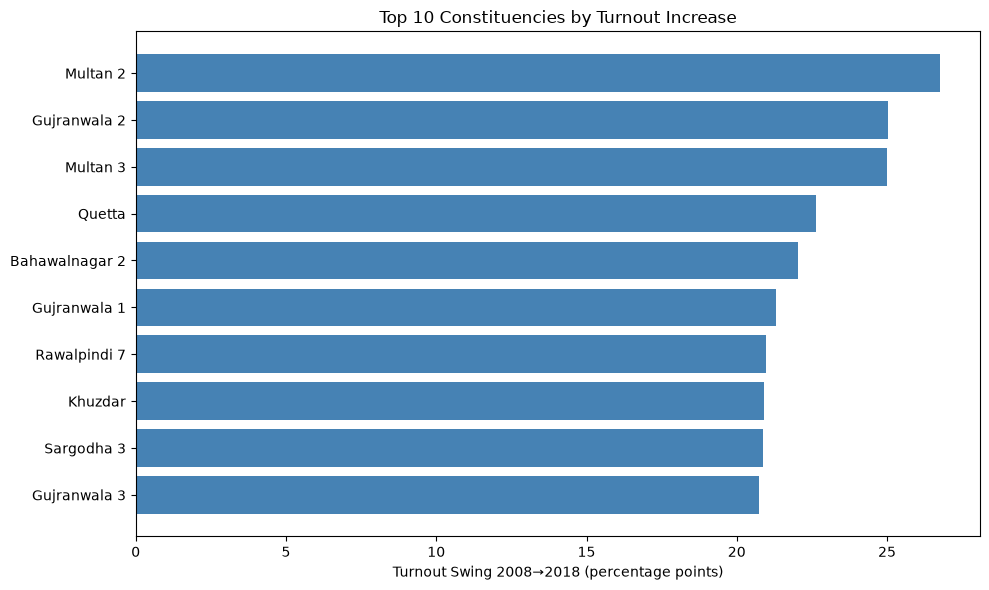

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(top10['constituency_name_2008'], top10['swing_08_18_pct'], color='steelblue')
plt.xlabel('Turnout Swing 2008→2018 (percentage points)')
plt.title('Top 10 Constituencies by Turnout Increase')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../visualizations/top10_swing.png', dpi=150)
plt.show()

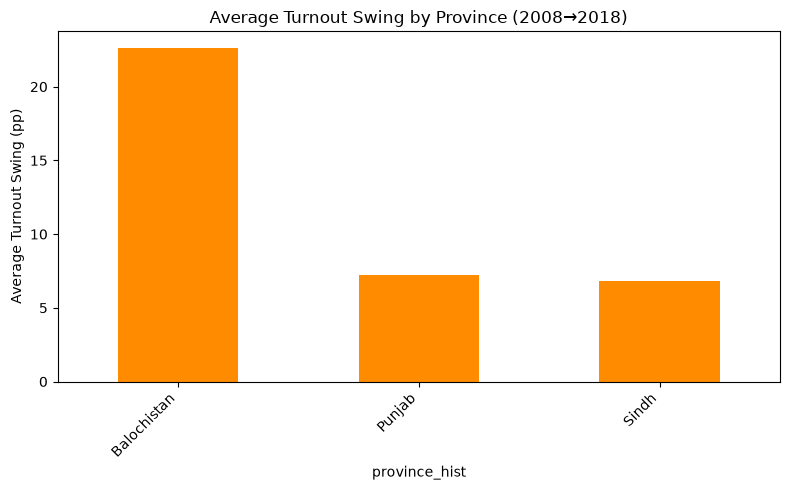

In [ ]:
province_avg = final_linked.groupby('province_hist')['swing_08_18_pct'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
province_avg.plot(kind='bar', color='darkorange')
plt.ylabel('Average Turnout Swing (pp)')
plt.title('Average Turnout Swing by Province (2008→2018)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visualizations/province_avg_swing.png', dpi=150)
plt.show()

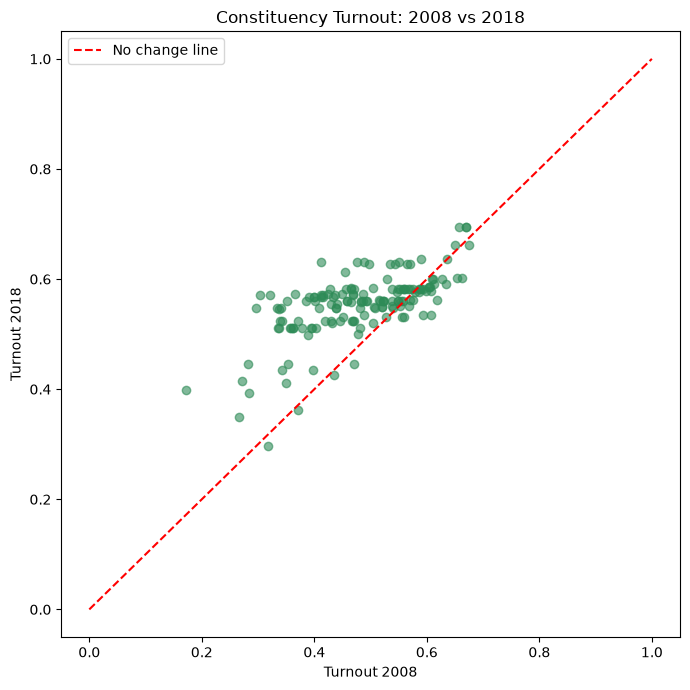

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(final_linked['turnout_2008'], final_linked['turnout'], alpha=0.6, color='seagreen')
plt.plot([0,1],[0,1], 'r--', label='No change line')
plt.xlabel('Turnout 2008')
plt.ylabel('Turnout 2018')
plt.title('Constituency Turnout: 2008 vs 2018')
plt.legend()
plt.tight_layout()
plt.savefig('../visualizations/scatter_2008_vs_2018.png', dpi=150)
plt.show()